<a href="https://colab.research.google.com/github/JamalMohideen2005/ITA0640-Machine-learning/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Coefficients:

              Feature  Coefficient
0         Video Hours     1.303391
1      Practice Tests    -3.084326
2  Avg Quiz Score (%)     1.321723

Intercept: -21.56370302474798

Interpretation:
For every 1 unit increase in Video Hours, Final Score increases by 1.30 marks (holding others constant).
For every 1 unit increase in Practice Tests, Final Score increases by -3.08 marks (holding others constant).
For every 1 unit increase in Avg Quiz Score (%), Final Score increases by 1.32 marks (holding others constant).

Predicted Final Score for new student: 72.11

Model Evaluation Metrics:
     Metric     Value
0  R² Score  0.994762
1       MAE  0.655362
2      RMSE  0.723729


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


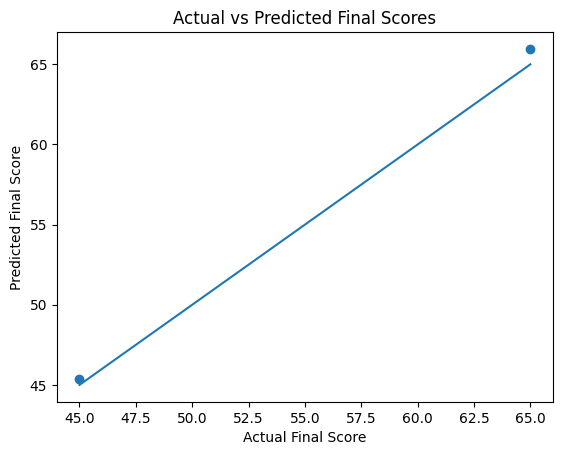

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


data = {
    "Video Hours": [5,8,6,10,4,12,7,9,3,11],
    "Practice Tests": [3,5,4,7,2,8,5,6,1,7],
    "Avg Quiz Score (%)": [60,70,65,80,55,85,72,78,50,82],
    "Final Score": [55,65,60,75,50,82,68,74,45,80]
}

df = pd.DataFrame(data)

X = df[["Video Hours", "Practice Tests", "Avg Quiz Score (%)"]]
y = df["Final Score"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)

# Print coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Model Coefficients:\n")
print(coefficients)

print("\nIntercept:", model.intercept_)

# Interpretation
print("\nInterpretation:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"For every 1 unit increase in {feature}, Final Score increases by {coef:.2f} marks (holding others constant).")

# -------------------------------------------------
# (d) Predict for new student
# -------------------------------------------------

new_student = np.array([[9, 6, 76]])
prediction = model.predict(new_student)

print("\nPredicted Final Score for new student:", round(prediction[0],2))

# -------------------------------------------------
# (e) Model Evaluation
# -------------------------------------------------

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

results = pd.DataFrame({
    "Metric": ["R² Score", "MAE", "RMSE"],
    "Value": [r2, mae, rmse]
})

print("\nModel Evaluation Metrics:")
print(results)

# -------------------------------------------------
# (f) Plot Actual vs Predicted
# -------------------------------------------------

plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)])
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Scores")
plt.show()